# 22 &middot; Fast Mass Springs &mdash; a constant-Hessian implicit solver

A cloth made of springs is stepped with **implicit (backward) Euler**: every step minimizes the
incremental potential below. Its spring term $\sum_s \tfrac{k_s}{2}(\lVert x_i-x_j\rVert - r_s)^2$ is
non-convex, so Newton must rebuild and **re-factorize** its Hessian at every iteration. Liu et al.
(*Fast Simulation of Mass-Spring Systems*, SIGGRAPH Asia 2013) split each spring with an auxiliary
direction so that a local/global solver needs one **constant** matrix, factorized **once** for the
whole simulation. The same structure underlies projective dynamics (Bouaziz et al. 2014).

$$
x_{n+1} = \arg\min_x \; \tfrac{1}{2h^2}\lVert x - \tilde x\rVert_M^2 \;-\; f_g^\top x
\;+\; \sum_s \tfrac{k_s}{2}\big(\lVert x_i-x_j\rVert - r_s\big)^2 \;+\; E_\text{pin}(x),
\qquad \tilde x = x_n + h\,v_n .
$$

Imports, and every tunable parameter of this notebook.

In [1]:
%matplotlib inline
import os
import time
import warnings
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
import igl
import simkit
import utils
warnings.filterwarnings("ignore", message=".*encountered in matmul")   # spurious macOS-BLAS matmul warnings

NOTEBOOK = "022_fast_mass_springs"                                 # this file's name
RESULTS_DIR = simkit.filesystem.notebook_results_path(NOTEBOOK)    # results/022_fast_mass_springs/
MEDIA_DIR = "media"                                                # tracked copies for the website
# cloth
NX, NY = 25, 25                 # grid resolution (vertices along x, y)
WIDTH, HEIGHT = 2.0, 2.0        # cloth size
# material and loads
YM = 80.0                       # spring modulus: each spring has stiffness k_s = YM / r_s^2
MASS = 1.0                      # mass of every particle
GRAVITY = -9.8                  # vertical gravitational acceleration
K_PIN = 1e7                     # soft-pin stiffness holding the two top corners
# time stepping
DT = 1.0 / 30.0                 # timestep h
N_STEPS = 240                   # implicit steps simulated (8 s)
N_INNER = 8                     # local/global iterations per step
# validation
FD_STEP = 1e-6                  # central-difference step of the gradient check
FD_NOISE = 0.05                 # size of the random pose perturbation for that check
SEED = 0                        # random seed of that perturbation
HESS_EVERY = 10                 # sample Newton's spring Hessian every this many steps
CONV_STEP = 5                   # step whose implicit solve is studied in detail
CONV_ITERS = 60                 # local/global iterations of that study
NEWTON_ITERS = 8                # Newton iterations of that study (they also give the reference minimum)
GAP_TOL = 1e-6                  # energy gap at which that study counts a solve as converged
TIMING_REPS = 7                 # repetitions of each timing (the minimum is kept)
TIMING_INNER = 20               # back-to-back calls per timing batch for the sub-millisecond local/global iteration
# video
N_FRAMES, FPS = 121, 30         # frames of the cloth video (every 2nd step) and playback rate

## The cloth

A $2\times2$ grid from libigl. Its springs are the unique triangle edges: horizontal and vertical
"structural" springs plus one "shear" diagonal per quad. Every particle has the same mass, and the two
**top corners** (blue squares) are pinned.

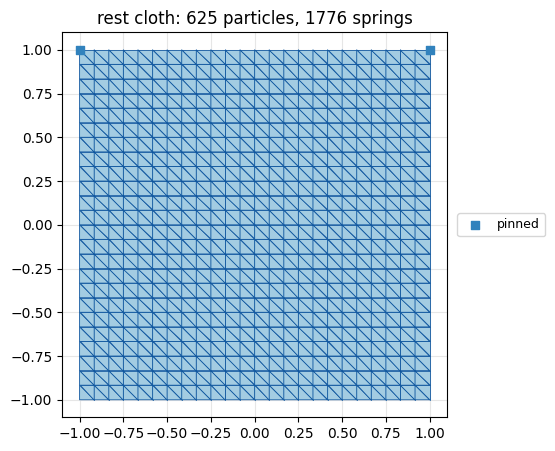

In [2]:
V_grid, T = igl.triangulated_grid(NX, NY)                 # unit square, NX x NY vertices
X = (V_grid - 0.5) * np.array([WIDTH, HEIGHT])           # centered WIDTH x HEIGHT cloth
n, dim = X.shape
E = simkit.edges(T)                                      # springs = unique triangle edges
top = X[:, 1] >= X[:, 1].max() - 1e-6
side = (X[:, 0] <= X[:, 0].min() + 1e-6) | (X[:, 0] >= X[:, 0].max() - 1e-6)
pin_idx = np.where(top & side)[0]                        # the two top corners
x_rest = X.reshape(-1, 1)

fig, ax = plt.subplots(figsize=(6.4, 5))
utils.plot_mesh(ax, X, T, pins=pin_idx, lw=0.6,
                title=f"rest cloth: {n} particles, {len(E)} springs")
ax.legend(loc="center left", bbox_to_anchor=(1.01, 0.5), fontsize=9)   # keep the corner pins visible
simkit.filesystem.save_figure(fig, os.path.join(RESULTS_DIR, "mesh.png"),
                              copy_to=os.path.join(MEDIA_DIR, "022_mesh.png"))
plt.show()

## Rest lengths and stiffnesses

Each spring stores its rest length $r_s$ and stiffness $k_s = \text{YM}/r_s^2$, which makes the energy
$\tfrac{\text{YM}}{2}\big((\lVert x_i-x_j\rVert - r_s)/r_s\big)^2$ a strain measure. The two fields below
have only two values: the shear diagonals are $\sqrt2$ longer than the structural springs, so they are
half as stiff.

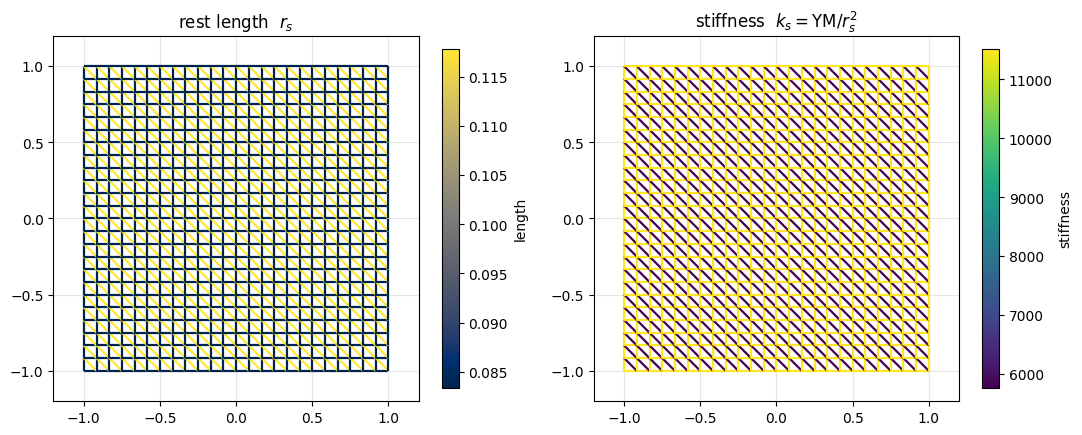

structural: r = 0.0833, k = 11520    shear: r = 0.1179, k = 5760


In [3]:
l0 = simkit.edge_lengths(X, E).reshape(-1, 1)            # rest length r_s
k = YM / l0 ** 2                                         # per-spring stiffness k_s
ones = np.ones_like(l0)                                  # unit quadrature weight per spring

fig, axes = plt.subplots(1, 2, figsize=(11, 4.6))
utils.plot_spring_network(axes[0], X, E, edge_values=l0, node_size=0, lw=1.0, cmap="cividis",
                          title="rest length  $r_s$", label="length")
utils.plot_spring_network(axes[1], X, E, edge_values=k, node_size=0, lw=1.0, cmap="viridis",
                          title="stiffness  $k_s = $YM$/r_s^2$", label="stiffness")
fig.tight_layout()
simkit.filesystem.save_figure(fig, os.path.join(RESULTS_DIR, "springs.png"),
                              copy_to=os.path.join(MEDIA_DIR, "022_springs.png"))
plt.show()
print(f"structural: r = {l0.min():.4f}, k = {k.max():.0f}    shear: r = {l0.max():.4f}, k = {k.min():.0f}")

## Constant operators

Built once from rest data: the diagonal mass matrix $M$, the gravity force $f_g = M g$, the
edge-difference operator $G$ (so $Gx$ stacks the spring vectors $x_i-x_j$, from
`simkit.edge_displacement_jacobian`), the spring weights $W = \mathrm{diag}(k_s)\otimes I$, and the
soft-pin penalty $(Q_\text{pin}, b_\text{pin})$ from `simkit.dirichlet_penalty`. The pins are a stiff
quadratic, so they too have a constant Hessian.

In [4]:
M = MASS * sp.sparse.identity(n * dim, format="csc")                        # particle masses
f_g = M @ np.tile([0.0, GRAVITY], n).reshape(-1, 1)                          # gravity force
G = sp.sparse.kron(simkit.edge_displacement_jacobian(X, E), sp.sparse.eye(dim)).tocsc()
W = sp.sparse.kron(sp.sparse.diags(k.ravel()), sp.sparse.eye(dim)).tocsc()
Q_pin, b_pin = simkit.dirichlet_penalty(pin_idx, X[pin_idx], n, K_PIN)

## The implicit-step objective

`cloth_step_system(x_tilde)` returns the energy, gradient and Hessian of one backward-Euler step, one
term per line: inertia towards the momentum target $\tilde x$, gravity, the springs (`simkit`'s
`mass_springs_*_z` with the prebuilt $G$) and the pins. Only the spring Hessian depends on $x$; that is
the block Newton has to re-assemble and re-factorize.

In [5]:
def cloth_step_system(x_tilde):
    """Backward-Euler step objective of the cloth: inertia + gravity + springs + soft pins."""

    def energy_func(x):
        E_inertia = simkit.energies.kinetic_energy(x - x_tilde, M, DT, 1.0)
        E_gravity = -(f_g.T @ x).item()
        E_spring = simkit.energies.mass_springs_energy_z(x, G, k, ones, l0)
        E_pin = simkit.energies.quadratic_energy(x, Q_pin, b_pin)
        E_total = E_inertia + E_gravity + E_spring + E_pin
        return E_total

    def gradient_func(x):
        g_inertia = simkit.energies.kinetic_gradient(x - x_tilde, M, DT, 1.0)
        g_gravity = -f_g
        g_spring = simkit.energies.mass_springs_gradient_z(x, G, k, ones, l0)
        g_pin = simkit.energies.quadratic_gradient(x, Q_pin, b_pin)
        g_total = g_inertia + g_gravity + g_spring + g_pin
        return g_total

    def hessian_func(x):
        H_inertia = simkit.energies.kinetic_hessian(M, DT, 1.0)
        H_spring = simkit.energies.mass_springs_hessian_z(x, G, k, ones, l0, psd=True)   # depends on x
        H_pin = simkit.energies.quadratic_hessian(Q_pin)
        H_total = H_inertia + H_spring + H_pin
        return H_total

    return energy_func, gradient_func, hessian_func

A central-difference check of the gradient at a randomly perturbed pose (`simkit.gradient_cfd`). The
relative error should be tiny.

In [6]:
rng = np.random.default_rng(SEED)
x_check = x_rest + FD_NOISE * rng.standard_normal(x_rest.shape)
energy_func, gradient_func, hessian_func = cloth_step_system(x_rest)
g_exact = gradient_func(x_check).ravel()
g_fd = simkit.gradient_cfd(lambda y: np.array(energy_func(y.reshape(-1, 1))), x_check.ravel(), FD_STEP)
print(f"gradient check: relative error {np.linalg.norm(g_fd - g_exact) / np.linalg.norm(g_exact):.2e}")

gradient check: relative error 2.81e-08


## The split: one constant matrix

Liu et al. write each spring as a minimum over an auxiliary vector $d_s$ of fixed length $r_s$ (below).
With $d$ fixed, the step objective is quadratic in $x$ with the system matrix
$A = M/h^2 + G^\top W G + Q_\text{pin}$. It is built from rest data only, so we factorize it once here.
Its sparsity pattern (plotted) is the mesh connectivity: two DOFs couple when a spring joins them.

$$
\tfrac{k_s}{2}\big(\lVert x_i-x_j\rVert - r_s\big)^2 = \min_{\lVert d_s\rVert = r_s}\; \tfrac{k_s}{2}\,\lVert (x_i-x_j) - d_s\rVert^2 .
$$

A: 1250 x 1250, 8354 nonzeros, factorized once in 1.2 ms


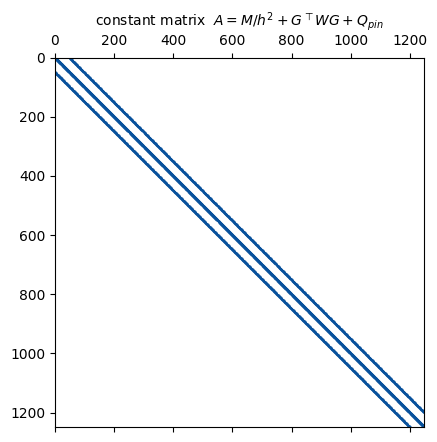

In [7]:
A_inertia = simkit.energies.kinetic_hessian(M, DT, 1.0)       # M / h^2
A_spring = G.T @ W @ G                                         # rest data only
A_pin = simkit.energies.quadratic_hessian(Q_pin)
A = (A_inertia + A_spring + A_pin).tocsc()

t0 = time.perf_counter()
solve_A = sp.sparse.linalg.factorized(A)                       # the ONLY factorization of the run
t_factor = time.perf_counter() - t0
print(f"A: {A.shape[0]} x {A.shape[1]}, {A.nnz} nonzeros, factorized once in {1e3 * t_factor:.1f} ms")

fig, ax = plt.subplots(figsize=(4.8, 4.8))
ax.spy(A, markersize=0.4, color=utils.MESH_EDGE)
ax.set_title(r"constant matrix  $A = M/h^2 + G^\top W G + Q_{pin}$", fontsize=10)
simkit.filesystem.save_figure(fig, os.path.join(RESULTS_DIR, "global_matrix.png"),
                              copy_to=os.path.join(MEDIA_DIR, "022_global_matrix.png"))
plt.show()

## Local and global steps

The **local** step fixes $x$ and sets each $d_s$ to the rest length along the current spring,
$d_s = r_s\,(x_i-x_j)/\lVert x_i-x_j\rVert$. The **global** step fixes $d$ and solves
$A\,x = M\tilde x/h^2 + f_g + G^\top W d - b_\text{pin}$ by back-substitution through the cached
factorization. `fast_mass_spring_step` alternates them `N_INNER` times with simkit's `block_coord`.

In [8]:
def local_step(x):
    """Project every spring onto its rest length: d_s = r_s (x_i - x_j) / ||x_i - x_j||."""
    d = (G @ x).reshape(-1, dim)
    d = l0 * d / np.linalg.norm(d, axis=1, keepdims=True)
    return d.reshape(-1, 1)

def global_step(x, d, x_tilde):
    """Solve A x = M x_tilde / h^2 + f_g + G^T W d - b_pin with the prefactored A."""
    rhs_inertia = M @ x_tilde / DT ** 2
    rhs_gravity = f_g
    rhs_spring = G.T @ (W @ d)
    rhs_pin = -b_pin
    rhs_total = rhs_inertia + rhs_gravity + rhs_spring + rhs_pin
    return solve_A(rhs_total).reshape(-1, 1)

def fast_mass_spring_step(x_curr, x_prev):
    """One backward-Euler step: N_INNER local/global iterations from x_curr."""
    v_curr = (x_curr - x_prev) / DT
    x_tilde = x_curr + DT * v_curr                              # momentum target
    x_next = simkit.solvers.block_coord(x_curr, lambda x, d: global_step(x, d, x_tilde), local_step,
                                        tolerance=0.0, max_iter=N_INNER)
    return x_next

## Drop the cloth

Released flat from rest, held at the two top corners, it settles under gravity. Backward Euler is
unconditionally stable, so the large step $h = 1/30$ with only 8 local/global iterations per step is
plenty, and the whole run reuses the one factorization.

In [9]:
x_prev = x_rest.copy()
x_curr = x_rest.copy()
states = [X.copy()]
t0 = time.perf_counter()
for step in range(N_STEPS):
    x_next = fast_mass_spring_step(x_curr, x_prev)
    x_prev, x_curr = x_curr, x_next
    states.append(x_curr.reshape(n, dim).copy())
t_sim = time.perf_counter() - t0
print(f"{N_STEPS} implicit steps in {t_sim:.2f} s ({1e3 * t_sim / N_STEPS:.2f} ms per step, one factorization)")

240 implicit steps in 0.17 s (0.72 ms per step, one factorization)


The simulation, every second step. The top edge sags between the pins and the cloth swings, then
settles. It leans slightly to one side, because every quad has its single shear spring along the same
diagonal.

In [10]:
frame_idx = np.linspace(0, N_STEPS, N_FRAMES).round().astype(int)
frames = [states[i] for i in frame_idx]
fig, anim = utils.animate_mesh(frames, T, lims=utils.auto_limits(frames, pad=0.3), fps=FPS,
                               figsize=(5.5, 5.5), pin_pts=X[pin_idx],
                               title="hanging cloth, fast mass springs")
video = simkit.filesystem.save_animation(anim, os.path.join(RESULTS_DIR, "cloth.mp4"), fps=FPS,
                                         copy_to=os.path.join(MEDIA_DIR, "022_cloth.mp4"))
plt.close(fig)
utils.embed_video(video)

The mechanical energy over the run, one term per line: kinetic $\tfrac12 v^\top M v$, gravitational
$-f_g^\top(x - x_\text{rest})$ and spring energy. Gravity feeds the springs and the motion; backward
Euler's numerical damping then drains the kinetic energy, so the total drops and flattens while the
swinging dies out.

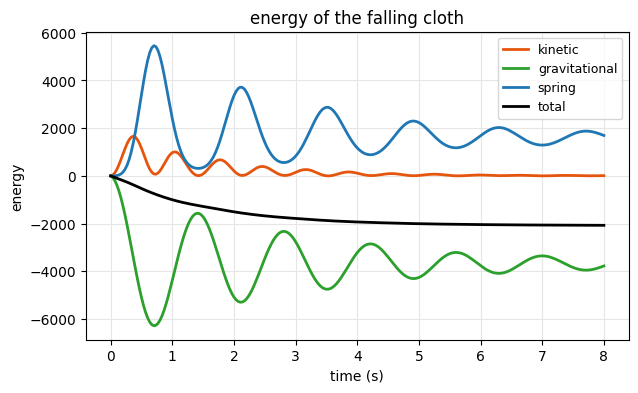

In [11]:
E_kinetic, E_gravity, E_spring, E_mech = [], [], [], []
for t in range(N_STEPS + 1):
    x_t = states[t].reshape(-1, 1)
    v_t = (states[t] - states[max(t - 1, 0)]).reshape(-1, 1) / DT
    e_kinetic = 0.5 * (v_t.T @ M @ v_t).item()
    e_gravity = -(f_g.T @ (x_t - x_rest)).item()
    e_spring = simkit.energies.mass_springs_energy_z(x_t, G, k, ones, l0)
    e_total = e_kinetic + e_gravity + e_spring
    E_kinetic.append(e_kinetic); E_gravity.append(e_gravity); E_spring.append(e_spring); E_mech.append(e_total)

times = DT * np.arange(N_STEPS + 1)
fig, ax = utils.line_plot(times, {"kinetic": E_kinetic, "gravitational": E_gravity,
                                  "spring": E_spring, "total": E_mech},
                          colors={"kinetic": "#e6550d", "gravitational": "#2ca02c",
                                  "spring": "#1f77b4", "total": "k"},
                          xlabel="time (s)", ylabel="energy", title="energy of the falling cloth",
                          figsize=(7, 4))
simkit.filesystem.save_figure(fig, os.path.join(RESULTS_DIR, "energy.png"),
                              copy_to=os.path.join(MEDIA_DIR, "022_energy.png"))
plt.show()

The per-spring strain $(\lVert x_i-x_j\rVert - r_s)/r_s$ of the final pose (red = stretched, blue =
compressed). The few springs next to the pins carry the whole cloth's weight and stretch the most, which
is why the corner triangles look elongated in the video; the hanging part is barely strained.

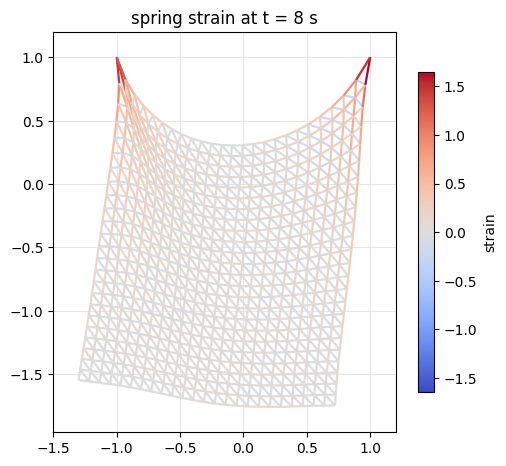

strain range: -0.301 .. +1.649


In [12]:
X_final = states[-1]
strain = (simkit.edge_lengths(X_final, E).reshape(-1, 1) - l0) / l0
s_max = np.abs(strain).max()
fig, ax = plt.subplots(figsize=(5.8, 5.2))
utils.plot_spring_network(ax, X_final, E, edge_values=strain, node_size=0, lw=1.0, cmap="coolwarm",
                          vmin=-s_max, vmax=s_max, label="strain",
                          title=f"spring strain at t = {N_STEPS * DT:.0f} s")
simkit.filesystem.save_figure(fig, os.path.join(RESULTS_DIR, "strain.png"),
                              copy_to=os.path.join(MEDIA_DIR, "022_strain.png"))
plt.show()
print(f"strain range: {strain.min():+.3f} .. {strain.max():+.3f}")

## Why it is fast: Newton's Hessian is not constant

Along the simulated trajectory we re-assemble Newton's spring Hessian $G^\top H_\text{spring}(x)\,G$ and
measure its relative change from the rest pose. It keeps changing as the cloth moves, so every Newton
iteration needs a fresh assembly and factorization. The local/global spring matrix $G^\top W G$ never
changes.

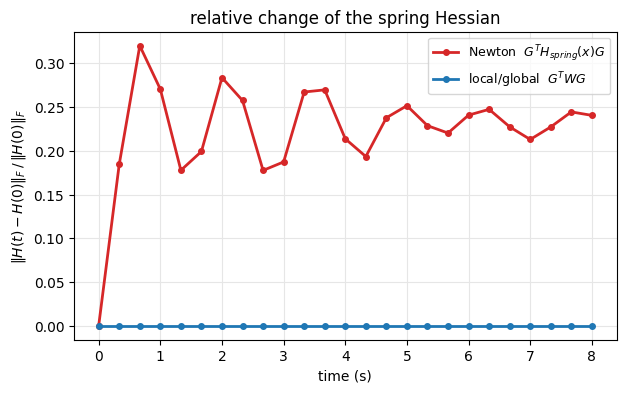

Newton spring Hessian changes by up to 32% of its rest norm; G^T W G by 0%


In [13]:
H_rest = simkit.energies.mass_springs_hessian_z(x_rest, G, k, ones, l0, psd=True)
sample_steps = np.arange(0, N_STEPS + 1, HESS_EVERY)
drift_newton = []
for t in sample_steps:
    H_t = simkit.energies.mass_springs_hessian_z(states[t].reshape(-1, 1), G, k, ones, l0, psd=True)
    drift_newton.append(sp.sparse.linalg.norm(H_t - H_rest) / sp.sparse.linalg.norm(H_rest))
drift_constant = np.zeros(len(sample_steps))                   # G^T W G is the same matrix at every step

fig, ax = utils.line_plot(DT * sample_steps, {"Newton  $G^T H_{spring}(x) G$": drift_newton,
                                              "local/global  $G^T W G$": drift_constant},
                          colors={"Newton  $G^T H_{spring}(x) G$": "#d62728",
                                  "local/global  $G^T W G$": "#1f77b4"},
                          xlabel="time (s)", ylabel=r"$\|H(t) - H(0)\|_F \,/\, \|H(0)\|_F$",
                          title="relative change of the spring Hessian", markers=True, figsize=(7, 4))
simkit.filesystem.save_figure(fig, os.path.join(RESULTS_DIR, "hessian_drift.png"),
                              copy_to=os.path.join(MEDIA_DIR, "022_hessian_drift.png"))
plt.show()
print(f"Newton spring Hessian changes by up to {100 * max(drift_newton):.0f}% of its rest norm; G^T W G by 0%")

## Convergence and cost of one step

We solve step `CONV_STEP` both ways from the same start $x_n$ and plot the energy gap to the minimum
$E^*$. Per iteration (left), local/global converges only linearly and Newton quadratically. But a Newton
iteration assembles and factorizes a new Hessian, while a local/global one is a projection plus a
back-substitution: in wall-clock time (right, the one-off factorization of $A$ amortized over the run)
local/global gets there first, and a whole simulation step of `N_INNER` iterations costs less than one
Newton iteration.

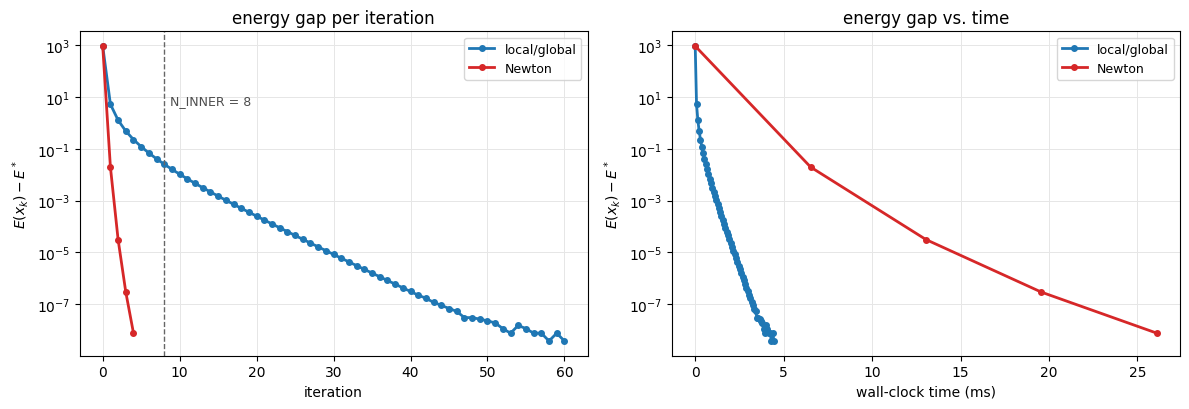

one iteration:   local/global   0.07 ms   Newton   6.52 ms   (88x)
one step (8 iterations): local/global    0.6 ms   refactorizing Newton   52.2 ms
to a gap of 1e-06:   local/global 37 iterations = 2.7 ms   Newton 3 iterations = 19.6 ms
gap after the 8 local/global iterations of a simulation step: 2.5e-02 (initial gap 9.3e+02)


In [14]:
x_prev = states[CONV_STEP - 1].reshape(-1, 1)
x_curr = states[CONV_STEP].reshape(-1, 1)
v_curr = (x_curr - x_prev) / DT
x_tilde = x_curr + DT * v_curr                                 # this step's momentum target
energy_func, gradient_func, hessian_func = cloth_step_system(x_tilde)
newton_iteration = lambda x: simkit.solvers.newton_solver(x, energy_func, gradient_func, hessian_func,
                                                          max_iter=1, do_line_search=True)
x = x_curr.copy()
E_newton = [energy_func(x)]
for _ in range(NEWTON_ITERS):
    x = newton_iteration(x)
    E_newton.append(energy_func(x))
x = x_curr.copy()
E_local_global = [energy_func(x)]
for _ in range(CONV_ITERS):
    x = global_step(x, local_step(x), x_tilde)
    E_local_global.append(energy_func(x))
E_star = min(min(E_newton), min(E_local_global))

t_lg = utils.best_time(lambda: global_step(x_curr, local_step(x_curr), x_tilde), inner=TIMING_INNER,
                       rep=TIMING_REPS)
t_newton = utils.best_time(lambda: newton_iteration(x_curr), inner=1, rep=TIMING_REPS)

gap_lg = np.array(E_local_global) - E_star
gap_newton = np.array(E_newton) - E_star
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
series = {"local/global": gap_lg, "Newton": gap_newton}
colors = {"local/global": "#1f77b4", "Newton": "#d62728"}
utils.residual_plot(series, ax=axes[0], colors=colors, markers=True, stagger=False,
                    xlabel="iteration", ylabel="$E(x_k) - E^*$", title="energy gap per iteration")
axes[0].axvline(N_INNER, color="0.4", ls="--", lw=1)
axes[0].text(N_INNER + 0.8, gap_lg[1], f"N_INNER = {N_INNER}", fontsize=9, color="0.3")
for name, gap, t_iter in (("local/global", gap_lg, t_lg), ("Newton", gap_newton, t_newton)):
    wall_ms = 1e3 * t_iter * np.arange(len(gap))
    axes[1].semilogy(wall_ms, np.where(gap > 0, gap, np.nan), "-o", ms=4, lw=2, color=colors[name], label=name)
axes[1].set_xlabel("wall-clock time (ms)")
axes[1].set_ylabel("$E(x_k) - E^*$")
axes[1].set_title("energy gap vs. time")
axes[1].grid(True, which="both", color="0.9", linewidth=0.7)
axes[1].legend(fontsize=9)
fig.tight_layout()
simkit.filesystem.save_figure(fig, os.path.join(RESULTS_DIR, "convergence.png"),
                              copy_to=os.path.join(MEDIA_DIR, "022_convergence.png"))
plt.show()
print(f"one iteration:   local/global {1e3 * t_lg:6.2f} ms   Newton {1e3 * t_newton:6.2f} ms   "
      f"({t_newton / t_lg:.0f}x)")
print(f"one step ({N_INNER} iterations): local/global {1e3 * N_INNER * t_lg:6.1f} ms   "
      f"refactorizing Newton {1e3 * N_INNER * t_newton:6.1f} ms")
it_lg = int(np.argmax(gap_lg <= GAP_TOL))
it_newton = int(np.argmax(gap_newton <= GAP_TOL))
print(f"to a gap of {GAP_TOL:g}:   local/global {it_lg} iterations = {1e3 * it_lg * t_lg:.1f} ms   "
      f"Newton {it_newton} iterations = {1e3 * it_newton * t_newton:.1f} ms")
print(f"gap after the {N_INNER} local/global iterations of a simulation step: {gap_lg[N_INNER]:.1e} "
      f"(initial gap {gap_lg[0]:.1e})")

## Takeaways

* **The split makes the system matrix constant.** An auxiliary direction per spring turns the global
  step into a quadratic solve with the fixed matrix $M/h^2 + G^\top W G$ (plus the pins). Factor it once;
  every step and every inner iteration is then a back-substitution.
* **This is the machinery of tutorial 21.** Local step = closed-form per-element projection (a spring
  onto its rest length, as ARAP projects a triangle onto its closest rotation). Global step = one
  prefactored linear solve. `simkit.solvers.block_coord` drives both.
* **Implicit + prefactored = fast and stable.** A big timestep stays stable, and a step costs a few
  sparse back-substitutions instead of repeated factorizations: the win reported by Liu et al. (2013).